# 📊 EDA — Phân Tích Xu Hướng Kinh Doanh (2012–2022)

## 1. Import Thư Viện <a id='1'></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Cấu hình style toàn cục
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid", {
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.alpha': 0.5
})

print("✅ Import thành công!")

✅ Import thành công!


## 2. Cấu Hình & Helper Functions <a id='2'>

In [24]:
# Formatter hiển thị số tiền theo tiếng Việt
def vn_formatter(x, pos):
    if x >= 1e6:
        return f'{x * 1e-6:,.0f} triệu'
    if x >= 1e3:
        return f'{x * 1e-3:,.0f} nghìn'
    return f'{x:,.0f}'

# Màu sắc nhất quán theo report
COLOR_BLUE    = '#3498DB'   # Golden Era / Doanh thu
COLOR_ORANGE  = '#E67E22'   # Số lượng đơn
COLOR_RED     = '#E74C3C'   # Decline / Cảnh báo
COLOR_DARK    = '#1F618D'   # Khách quay lại (Repeat)
COLOR_LIGHT   = '#A9CCE3'   # Khách mới (New)
COLOR_CR_LINE = '#CB4335'   # Đường Retention Rate

# Mốc cấu trúc gãy
MILESTONE = pd.Timestamp('2019-01-01')

print("✅ Config OK")

✅ Config OK


## 3. Load Dữ Liệu <a id='3'></a>

In [25]:
sales   = pd.read_csv('Data/sales.csv',       parse_dates=['Date'])
orders  = pd.read_csv('Data/orders.csv',      parse_dates=['order_date'])
traffic = pd.read_csv('Data/web_traffic.csv', parse_dates=['date'])

print(f"Sales   : {sales.shape}")
print(f"Orders  : {orders.shape}")
print(f"Traffic : {traffic.shape}")

Sales   : (3833, 3)
Orders  : (646945, 8)
Traffic : (3652, 7)


In [26]:
# Preview từng bảng
print("=== SALES ===")
display(sales.head(3))

print("=== ORDERS ===")
display(orders.head(3))

print("=== TRAFFIC ===")
display(traffic.head(3))

=== SALES ===


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84


=== ORDERS ===


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct


=== TRAFFIC ===


,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct


## 4. Xử Lý & Tổng Hợp Dữ Liệu <a id='4'></a>

### 4.1 Doanh thu & Đơn hàng theo tháng

In [27]:
monthly_rev = sales.resample('MS', on='Date')['Revenue'].sum().reset_index()
monthly_ord = orders.resample('MS', on='order_date').size().reset_index(name='orders')

df_monthly = pd.merge(monthly_rev, monthly_ord, left_on='Date', right_on='order_date')

print(f"df_monthly: {df_monthly.shape}")
display(df_monthly.head(3))

df_monthly: (126, 4)


,Date,Revenue,order_date,orders
0,2012-07-01,1.304068e+08,2012-07-01,5294
1,2012-08-01,1.590892e+08,2012-08-01,6427
2,2012-09-01,1.293071e+08,2012-09-01,5219


### 4.2 Phân tích Retention — Khách mới vs. Khách quay lại

> **Chú thích định nghĩa:**
> - **Khách mới (New):** Khách thực hiện đơn hàng lần đầu tiên
> - **Khách quay lại (Repeat):** Khách phát sinh đơn hàng sau đơn hàng đầu tiên
> - Một khách có thể thuộc cả hai nhóm trong cùng một năm nếu vừa mua lần đầu vừa mua lặp lại ngay sau đó

In [28]:
# Xác định lần đặt hàng đầu tiên của mỗi khách
first_orders = (
    orders
    .groupby('customer_id')['order_date']
    .min()
    .reset_index()
    .rename(columns={'order_date': 'first_date'})
)

df_ret = pd.merge(orders, first_orders, on='customer_id')
df_ret['type'] = np.where(
    df_ret['order_date'] == df_ret['first_date'],
    'New', 'Repeat'
)

# Thống kê retention theo năm
retention_stats = (
    df_ret
    .groupby([df_ret['order_date'].dt.year, 'type'])['customer_id']
    .nunique()
    .unstack(fill_value=0)
)
retention_stats['Rate'] = (
    retention_stats['Repeat']
    / (retention_stats['New'] + retention_stats['Repeat'])
    * 100
)

print("Retention Stats (2012–2022):")
display(retention_stats)

Retention Stats (2012–2022):


type,New,Repeat,Rate
order_date,,,
2012,22068,6446,22.606439
2013,25099,23230,48.066378
2014,13293,30219,69.449807
2015,8828,33563,79.174825
2016,6392,35467,84.729688
2017,4789,35434,88.093877
2018,3717,34563,90.289969
2019,1898,25531,93.080316
2020,1500,22926,93.859003


### 4.3 Traffic & Đơn hàng theo ngày — Tính CR & Moving Average

In [9]:
daily_traffic = traffic.groupby('date')['sessions'].sum().reset_index()
daily_orders  = orders.groupby('order_date').size().reset_index(name='orders')

df_daily = pd.merge(
    daily_traffic, daily_orders,
    left_on='date', right_on='order_date',
    how='left'
).fillna(0)

# Conversion Rate hàng ngày
df_daily['CR'] = df_daily['orders'] / (df_daily['sessions'] + 1)

# 30-day Moving Average CR (dùng cho biểu đồ — khớp với report)
df_daily = df_daily.sort_values('date')
df_daily['CR_MA30'] = df_daily['CR'].rolling(window=30, min_periods=1).mean()

# Phân kỳ thời gian
df_daily['Period'] = np.where(
    df_daily['date'].dt.year <= 2018,
    '2013–2018 (Golden Era)',
    '2019–2022 (Decline)'
)

print(f"df_daily: {df_daily.shape}")
display(df_daily.head(3))

df_daily: (3652, 7)


,date,sessions,order_date,orders,CR,CR_MA30,Period
0,2013-01-01,9760,2013-01-01,288,0.029505,0.029505,2013–2018 (Golden Era)
1,2013-01-02,10456,2013-01-02,47,0.004495,0.017000,2013–2018 (Golden Era)
2,2013-01-03,10076,2013-01-03,81,0.008038,0.014013,2013–2018 (Golden Era)


## 5. Trực Quan Hóa <a id='5'></a>

### 📌 Biểu đồ 1 — Biến Động Doanh Thu & Quy Mô Đơn Hàng (2012–2022)

> **Insight:** Doanh thu và đơn hàng đạt đỉnh giai đoạn **2016–2018**, sau đó suy thoái mạnh từ 2019.  
> Số đơn hàng sau 2019 giảm hơn **50%**, chỉ dao động 4,000–5,000 đơn/tháng.

### 📌 Biểu đồ 2 — Seasonal Heatmap: Điểm Nóng Mùa Vụ

> **Insight:** Mô hình mùa vụ lặp lại rõ rệt.  
> - Đỉnh doanh thu tại **Q2** (tháng 4–6) — nhu cầu cao nhất trong năm  
> - Giảm dần vào **Q3**, đáy tại **Q4 và Q1** năm sau

### 📌 Biểu đồ 3 — Phân Tích Cơ Cấu Khách Hàng & Retention Rate (2012–2022)

> **Insight (từ report):**
> - Tổng khách hàng giảm gần **50%** so với đỉnh 2013 (từ ~48,200 xuống ~24,700 khách)
> - Khách mới giai đoạn 2019–2022 chỉ còn ~**1,200 khách/năm** — giảm gần **20 lần** so với thời kỳ đỉnh cao
> - Tỷ trọng khách cũ **94.7%** là hệ quả thiếu hụt luồng khách mới, không phải thành công giữ chân
> - Doanh nghiệp đang tồn tại dựa trên tệp khách cũ đang thu hẹp — tiến gần đến **"điểm gãy" về quy mô**

### 📌 Biểu đồ 4 — Bằng Chứng Suy Giảm Chất Lượng Traffic

> **Insight:**
> - **2013–2018:** Tương quan thuận bền vững giữa Sessions và Orders — kênh chuyển đổi lành mạnh
> - **2019–2022:** Đứt gãy tương quan hoàn toàn. Sessions tăng cao kỷ lục (>50,000) nhưng Orders giảm sâu (<200 đơn/tháng)
> - Vấn đề cốt lõi: **suy giảm nghiêm trọng của Conversion Rate**, không phải thiếu traffic

### 📌 Biểu đồ 5 — Conversion Rate Trend (30-day Moving Average)

> **Insight:**
> - CR duy trì ổn định **0.8%–1.4%** giai đoạn 2013–2018
> - Sau điểm gãy cấu trúc 2019: CR sụp đổ xuống dưới **0.4%** và không phục hồi
> - Đây là nguyên nhân cốt lõi khiến đơn hàng giảm dù traffic vẫn cao

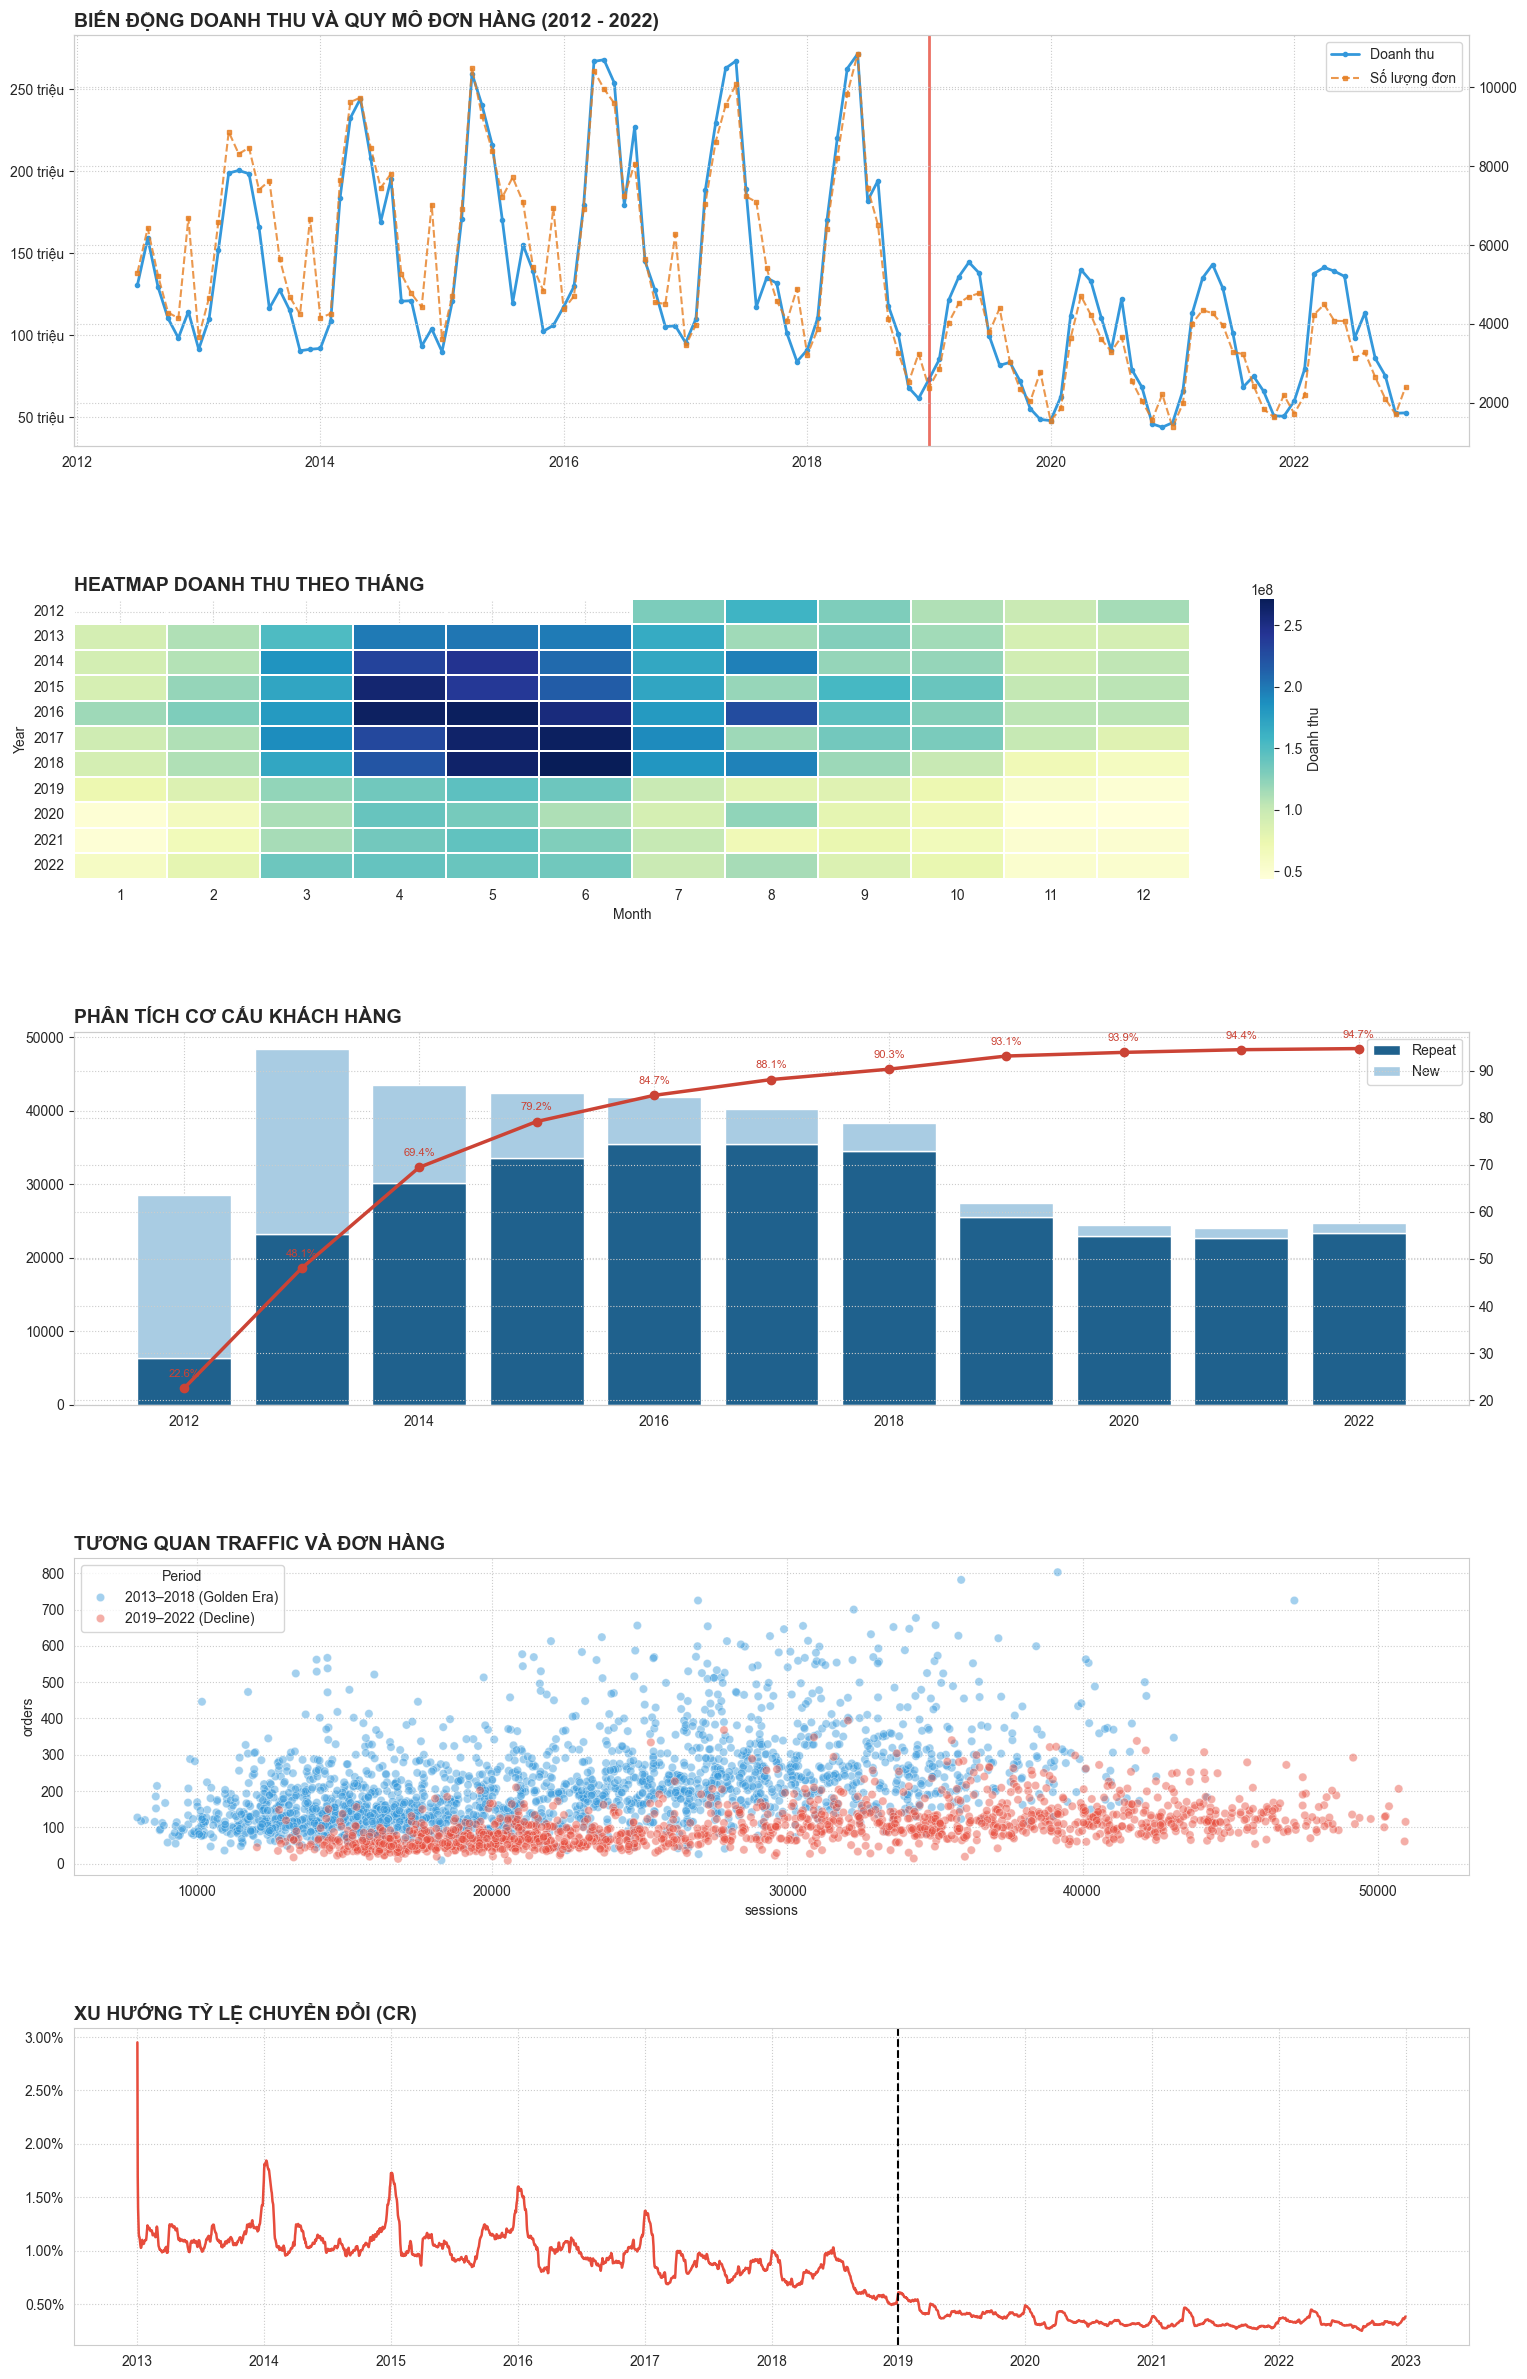

✅ Đã vẽ xong 5 biểu đồ và lưu vào thư mục output!


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
from matplotlib.ticker import PercentFormatter

# --- 1. Cấu hình & Helper Functions ---
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': ':', 'grid.alpha': 0.5})

def vn_formatter(x, pos):
    if x >= 1e6: return f'{x * 1e-6:,.0f} triệu'
    if x >= 1e3: return f'{x * 1e-3:,.0f} nghìn'
    return f'{x:,.0f}'

COLOR_BLUE, COLOR_ORANGE, COLOR_RED = '#3498DB', '#E67E22', '#E74C3C'
COLOR_DARK, COLOR_LIGHT, COLOR_CR_LINE = '#1F618D', '#A9CCE3', '#CB4335'
MILESTONE = pd.Timestamp('2019-01-01')

# --- 2. Load & Xử lý dữ liệu (Phải chạy trước khi vẽ) ---
try:
    sales = pd.read_csv('Data/sales.csv', parse_dates=['Date'])
    orders = pd.read_csv('Data/orders.csv', parse_dates=['order_date'])
    traffic = pd.read_csv('Data/web_traffic.csv', parse_dates=['date'])
    
    # Gom dữ liệu hàng tháng
    monthly_rev = sales.resample('MS', on='Date')['Revenue'].sum().reset_index()
    monthly_ord = orders.resample('MS', on='order_date').size().reset_index(name='orders')
    df_monthly = pd.merge(monthly_rev, monthly_ord, left_on='Date', right_on='order_date')

    # Xử lý Retention
    first_orders = orders.groupby('customer_id')['order_date'].min().reset_index().rename(columns={'order_date': 'first_date'})
    df_ret = pd.merge(orders, first_orders, on='customer_id')
    df_ret['type'] = np.where(df_ret['order_date'] == df_ret['first_date'], 'New', 'Repeat')
    retention_stats = df_ret.groupby([df_ret['order_date'].dt.year, 'type'])['customer_id'].nunique().unstack(fill_value=0)
    retention_stats['Rate'] = retention_stats['Repeat'] / (retention_stats['New'] + retention_stats['Repeat']) * 100

    # Xử lý Traffic & CR
    daily_traffic = traffic.groupby('date')['sessions'].sum().reset_index()
    daily_orders = orders.groupby('order_date').size().reset_index(name='orders')
    df_daily = pd.merge(daily_traffic, daily_orders, left_on='date', right_on='order_date', how='left').fillna(0)
    df_daily['CR'] = df_daily['orders'] / (df_daily['sessions'] + 1)
    df_daily['CR_MA30'] = df_daily['CR'].rolling(window=30, min_periods=1).mean()
    df_daily['Period'] = np.where(df_daily['date'].dt.year <= 2018, '2013–2018 (Golden Era)', '2019–2022 (Decline)')

    # --- 3. TRỰC QUAN HÓA (GOM VÀO 1 CELL) ---
    fig = plt.figure(figsize=(18, 30))
    gs = fig.add_gridspec(5, 1, hspace=0.45, height_ratios=[1.1, 0.75, 1, 0.85, 0.85])

    # Biểu đồ 1: Doanh thu & Đơn hàng (Dữ liệu thô, không smooth)
    ax1 = fig.add_subplot(gs[0])
    ax1_twin = ax1.twinx()
    ax1.plot(df_monthly['Date'], df_monthly['Revenue'], color=COLOR_BLUE, lw=2, marker='o', ms=3, label='Doanh thu')
    ax1_twin.plot(df_monthly['Date'], df_monthly['orders'], color=COLOR_ORANGE, lw=1.5, ls='--', marker='s', ms=3, alpha=0.8, label='Số lượng đơn')
    ax1.set_title('BIẾN ĐỘNG DOANH THU VÀ QUY MÔ ĐƠN HÀNG (2012 - 2022)', loc='left', fontsize=14, fontweight='bold')
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(vn_formatter))
    ax1.axvline(MILESTONE, color=COLOR_RED, ls='-', lw=2, alpha=0.8)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1_twin.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    # Biểu đồ 2: Heatmap
    ax2 = fig.add_subplot(gs[1])
    pivot_rev = df_monthly.assign(Year=df_monthly['Date'].dt.year, Month=df_monthly['Date'].dt.month).pivot(index='Year', columns='Month', values='Revenue')
    sns.heatmap(pivot_rev, cmap='YlGnBu', ax=ax2, cbar_kws={'label': 'Doanh thu'}, linewidths=0.3)
    ax2.set_title('HEATMAP DOANH THU THEO THÁNG', loc='left', fontsize=14, fontweight='bold')

    # Biểu đồ 3: Cơ cấu khách hàng (New vs Repeat)
    ax3 = fig.add_subplot(gs[2])
    ax3_twin = ax3.twinx()
    ax3.bar(retention_stats.index, retention_stats['Repeat'], color=COLOR_DARK, label='Repeat')
    ax3.bar(retention_stats.index, retention_stats['New'], bottom=retention_stats['Repeat'], color=COLOR_LIGHT, label='New')
    ax3_twin.plot(retention_stats.index, retention_stats['Rate'], color=COLOR_CR_LINE, marker='o', lw=2.5)
    for yr, rate in retention_stats['Rate'].items():
        ax3_twin.annotate(f'{rate:.1f}%', xy=(yr, rate), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8, color=COLOR_CR_LINE)
    ax3.set_title('PHÂN TÍCH CƠ CẤU KHÁCH HÀNG', loc='left', fontsize=14, fontweight='bold')
    ax3.legend(loc='upper right')

    # Biểu đồ 4: Scatter Traffic chất lượng
    ax4 = fig.add_subplot(gs[3])
    sns.scatterplot(data=df_daily, x='sessions', y='orders', hue='Period', palette={'2013–2018 (Golden Era)': COLOR_BLUE, '2019–2022 (Decline)': COLOR_RED}, alpha=0.45, ax=ax4)
    ax4.set_title('TƯƠNG QUAN TRAFFIC VÀ ĐƠN HÀNG', loc='left', fontsize=14, fontweight='bold')

    # Biểu đồ 5: CR Trend
    ax5 = fig.add_subplot(gs[4])
    ax5.plot(df_daily['date'], df_daily['CR_MA30'] * 100, color=COLOR_RED, lw=1.8, label='Moving Avg CR')
    ax5.axvline(MILESTONE, color='black', ls='--')
    ax5.set_title('XU HƯỚNG TỶ LỆ CHUYỂN ĐỔI (CR)', loc='left', fontsize=14, fontweight='bold')
    ax5.yaxis.set_major_formatter(PercentFormatter(decimals=2))

    # Lưu và Hiển thị
    os.makedirs('output', exist_ok=True)
    plt.savefig('output/Datathon_Final_Charts.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Đã vẽ xong 5 biểu đồ và lưu vào thư mục output!")

except Exception as e:
    print(f"❌ Lỗi: {e}. Hãy đảm bảo file CSV nằm trong thư mục Data/.")